# Exploring Systemic vs. Idiosyncratic Feature Selection

**Hypothesis:** Are frequently selected features (like the VIX or financial crises) driven by specific macroeconomic periods where they become active for *all* stocks simultaneously, or is their selection idiosyncratic across different stocks over time?

To answer this, we will calculate the **Cross-Sectional Selection Rate** for each feature over time:
$$CSR_{i,t} = \frac{\text{Number of stocks selecting feature } i \text{ at time } t}{\text{Total number of active stocks at time } t}$$

In [5]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# --- Paths (Adjust OUT_DIR to your specific folder structure) ---
H5_PATH = r'C:\Users\jonat\Lasso_paper\Results\Estimation\Cross_Sectional\betas.h5'

print(f"Loading data from {H5_PATH}...")

with h5py.File(H5_PATH, 'r') as f:
    # Load the betas tensor: shape (n_stocks, n_topics, n_dates)
    T_betas = f['betas'][:]
    
    # HDF5 string datasets need to be decoded
    topics = np.array([t.decode('utf-8') for t in f['topics'][:]])
    dates_raw = [d.decode('utf-8') for d in f['dates'][:]]
    stocks = np.array([s.decode('utf-8') for s in f['stocks'][:]])

# Convert dates to pandas DatetimeIndex for easier time-series manipulation
dates = pd.to_datetime(dates_raw)

print(f"Loaded Tensor Shape: {T_betas.shape} (Stocks: {len(stocks)}, Topics: {len(topics)}, Dates: {len(dates)})")

Loading data from C:\Users\jonat\Lasso_paper\Results\Estimation\Cross_Sectional\betas.h5...
Loaded Tensor Shape: (1296, 190, 1657) (Stocks: 1296, Topics: 190, Dates: 1657)


In [6]:
# Create a boolean mask of selections (True if beta != 0 and not NaN)
selections = (T_betas != 0) & ~np.isnan(T_betas)

# Find how many stocks are "active" (have non-NaN beta vectors) on each date
# Shape: (n_dates,)
active_stocks_per_day = (~np.isnan(T_betas)).any(axis=1).sum(axis=0)

# Calculate the cross-sectional selection rate: Shape (n_topics, n_dates)
# Using np.errstate to safely ignore division by zero on days with no active stocks
with np.errstate(divide='ignore', invalid='ignore'):
    xs_sel_rate = selections.sum(axis=0) / active_stocks_per_day

# Clean up any resulting NaNs (e.g., days where active_stocks_per_day was 0)
xs_sel_rate[np.isnan(xs_sel_rate)] = 0.0

# Calculate the overall mean selection rate across all days to rank features
overall_mean_sel = xs_sel_rate.mean(axis=1)
top_idx = np.argsort(overall_mean_sel)[::-1]
top_topics = topics[top_idx]

print("Top 10 Most Frequently Selected Features:")
for i in range(10):
    idx = top_idx[i]
    print(f"{i+1:2d}. {topics[idx]:<35s} (Avg XS Rate: {overall_mean_sel[idx]*100:.2f}%)")

Top 10 Most Frequently Selected Features:
 1. VIX_Volatility_Index                (Avg XS Rate: 6.57%)
 2. Announce_plan                       (Avg XS Rate: 5.99%)
 3. Financial_reports                   (Avg XS Rate: 5.70%)
 4. Credit_ratings                      (Avg XS Rate: 4.66%)
 5. Germany                             (Avg XS Rate: 4.40%)
 6. Economic_growth                     (Avg XS Rate: 4.14%)
 7. China                               (Avg XS Rate: 3.91%)
 8. Job_cuts                            (Avg XS Rate: 3.61%)
 9. C-suite                             (Avg XS Rate: 3.53%)
10. Broadcasting                        (Avg XS Rate: 3.42%)


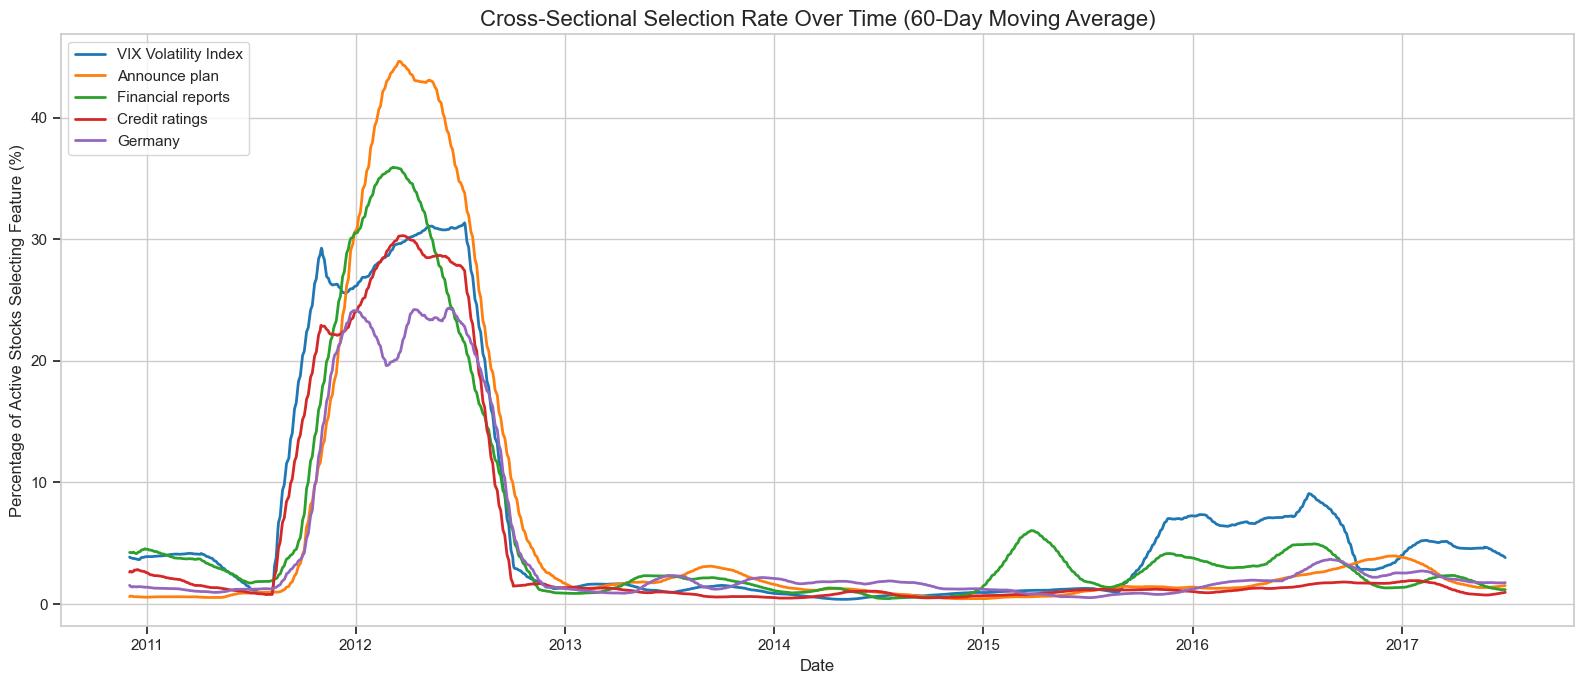

In [7]:
plt.figure(figsize=(16, 7))

# Number of top features to plot
N_TOP_PLOT = 5

for i in range(N_TOP_PLOT):
    topic_idx = top_idx[i]
    topic_name = topics[topic_idx]
    
    # Create a pandas series for rolling mean
    series = pd.Series(xs_sel_rate[topic_idx] * 100, index=dates)
    smoothed = series.rolling(window=60, min_periods=1).mean()
    
    plt.plot(smoothed.index, smoothed.values, label=topic_name.replace('_', ' '), linewidth=2)

plt.title("Cross-Sectional Selection Rate Over Time (60-Day Moving Average)", fontsize=16)
plt.ylabel("Percentage of Active Stocks Selecting Feature (%)", fontsize=12)
plt.xlabel("Date", fontsize=12)

# Formatting the x-axis
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

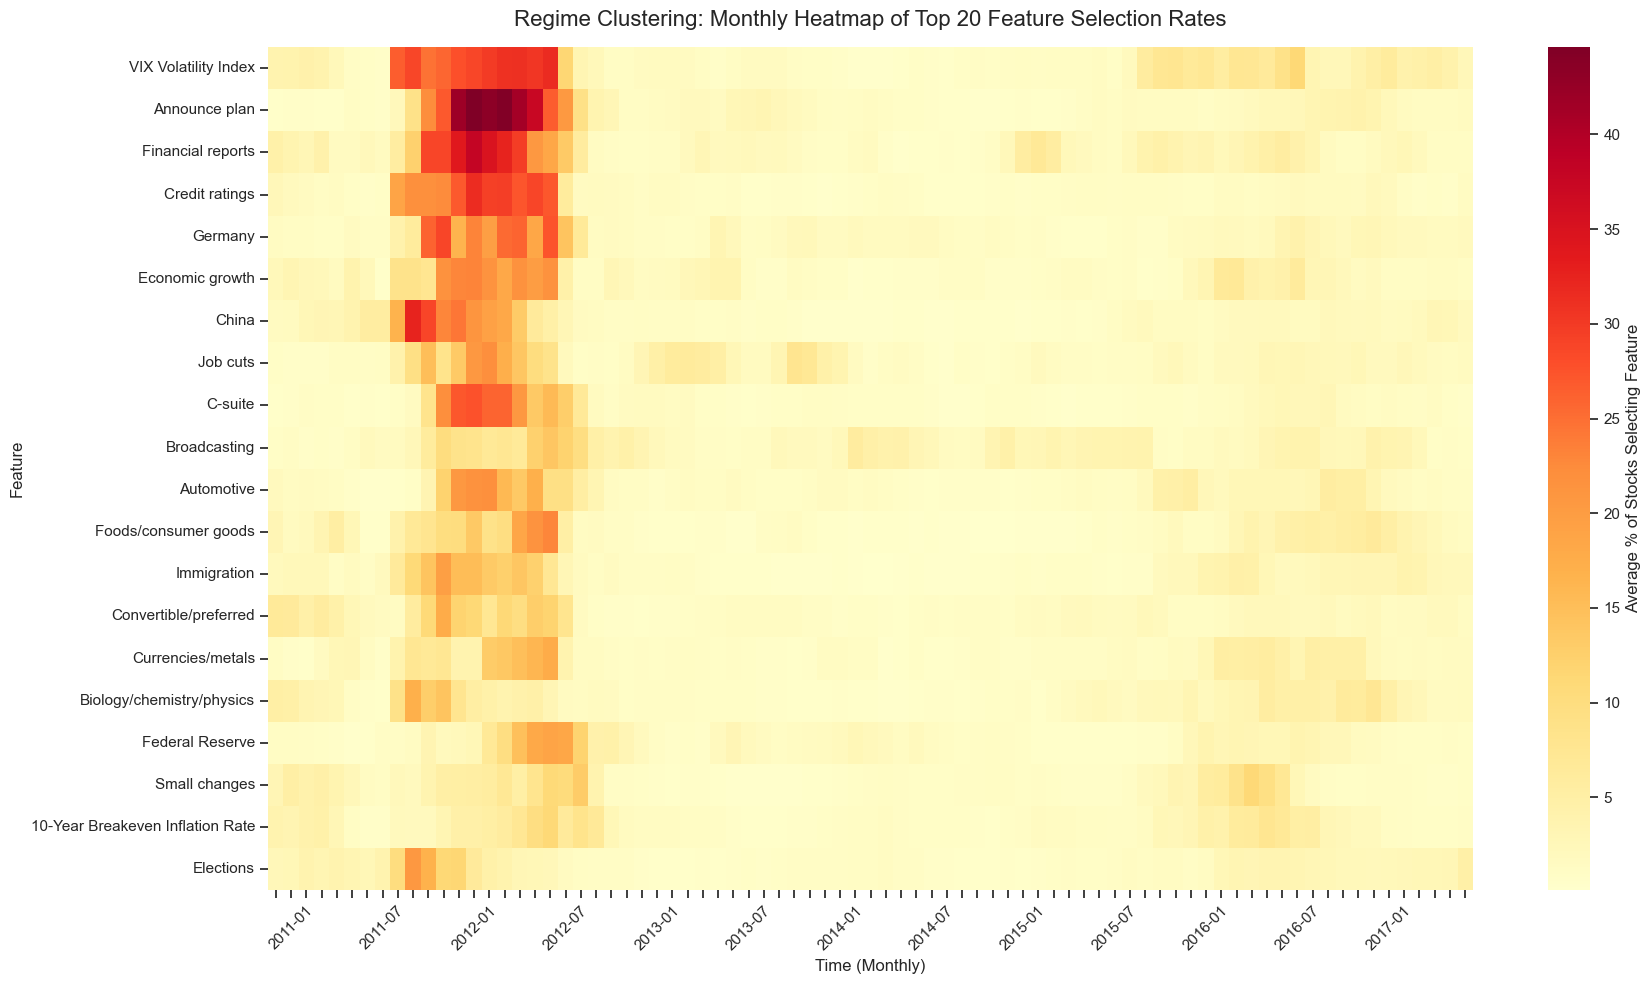

In [8]:
# Select the top 20 features for the heatmap
N_HEATMAP = 20
top_20_idx = top_idx[:N_HEATMAP]

# Create a DataFrame for easier time-based resampling
df_heatmap = pd.DataFrame(
    xs_sel_rate[top_20_idx].T * 100, 
    index=dates, 
    columns=[t.replace('_', ' ') for t in topics[top_20_idx]]
)

# Resample to monthly averages
df_monthly = df_heatmap.resample('ME').mean()

# To make the x-axis labels cleaner, format the datetime index to strings
x_labels = [d.strftime('%Y-%m') if d.month in [1, 7] else '' for d in df_monthly.index]

plt.figure(figsize=(18, 10))
ax = sns.heatmap(
    df_monthly.T, 
    cmap="YlOrRd", 
    xticklabels=x_labels,
    cbar_kws={'label': 'Average % of Stocks Selecting Feature'}
)

plt.title("Regime Clustering: Monthly Heatmap of Top 20 Feature Selection Rates", fontsize=16, pad=15)
plt.xlabel("Time (Monthly)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

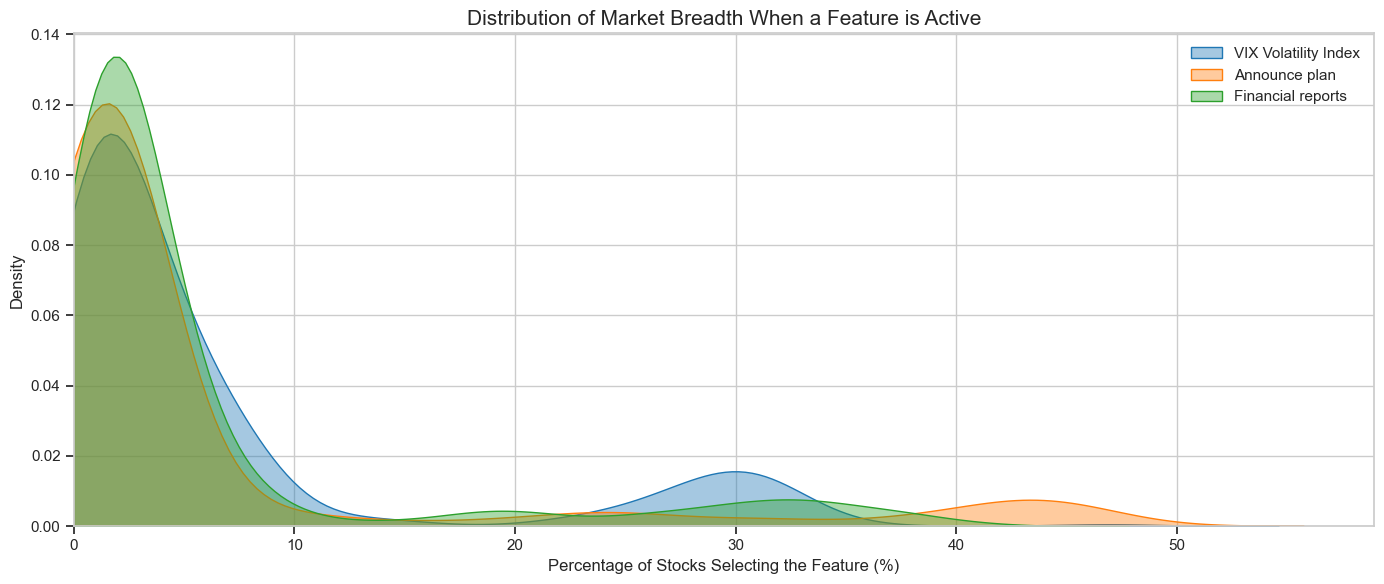

In [9]:
plt.figure(figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i in range(3): # Let's look at the top 3 features
    topic_idx = top_idx[i]
    topic_name = topics[topic_idx].replace('_', ' ')
    
    # Get rates only for days where the feature was selected by > 0% of the market
    active_days_rates = xs_sel_rate[topic_idx] * 100
    active_days_rates = active_days_rates[active_days_rates > 0]
    
    sns.kdeplot(active_days_rates, fill=True, label=topic_name, color=colors[i], alpha=0.4)

plt.title("Distribution of Market Breadth When a Feature is Active", fontsize=15)
plt.xlabel("Percentage of Stocks Selecting the Feature (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=11)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

Connecting to FRED API to download actual VIX data...
Loading features from C:\Users\jonat\Lasso_paper\Data\clean_data\final_macro_topic_features.csv...

Running HAC Robust OLS Regression...

--- Hypothesis Test: Does the Actual VIX drive the selection of 'VIX_Volatility_Index'? ---
                               OLS Regression Results                               
Dep. Variable:     CSR_VIX_Volatility_Index   R-squared:                       0.332
Model:                                  OLS   Adj. R-squared:                  0.331
Method:                       Least Squares   F-statistic:                     76.80
Date:                      Fri, 24 Apr 2026   Prob (F-statistic):           4.59e-18
Time:                              16:38:38   Log-Likelihood:                -5780.3
No. Observations:                      1657   AIC:                         1.156e+04
Df Residuals:                          1655   BIC:                         1.158e+04
Df Model:                           

C:\Users\jonat\AppData\Local\Temp\ipykernel_43624\2269423511.py:43: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  reg_df = pd.concat([y_csr, x_macro], axis=1).reindex(dates).dropna()


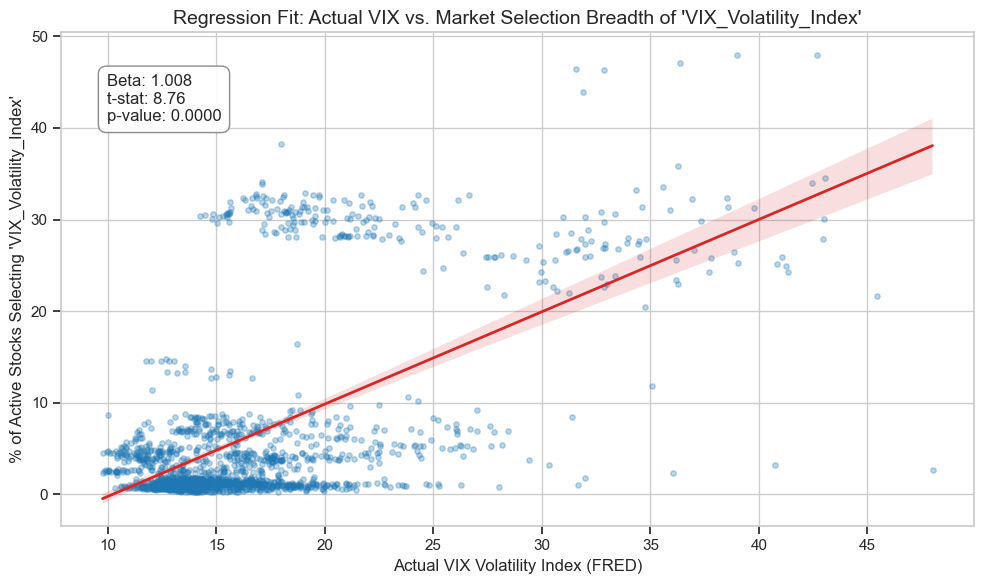

In [13]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import warnings

# Suppress warnings for clean output
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Configuration & Paths
FRED_API_KEY = 'db7bb3acaf0db1968dfd92d4fc89121d'
FEATURES_CSV = r'C:\Users\jonat\Lasso_paper\Data\clean_data\final_macro_topic_features.csv'

# 2. Fetch the raw VIX index directly from FRED
print("Connecting to FRED API to download actual VIX data...")
fred = Fred(api_key=FRED_API_KEY)
# We pull data using the min and max of our existing 'dates' index to ensure full coverage
vix_series = fred.get_series('VIXCLS', observation_start=dates.min(), observation_end=dates.max())

# Convert to DataFrame, forward-fill missing weekend/holiday values, and set name
df_vix = pd.DataFrame(vix_series, columns=['Actual_VIX'])
df_vix.index.name = 'date'
df_vix.ffill(inplace=True)

# 3. Load the pre-processed features (optional step if you want to include other controls later)
print(f"Loading features from {FEATURES_CSV}...")
df_features = pd.read_csv(FEATURES_CSV, index_col=0, parse_dates=True)
df_features.columns = [str(c).replace(' ', '_') for c in df_features.columns]

# 4. Define Dependent (Y) and Independent (X) variables
# Get the most selected feature from the earlier analysis
target_feature = top_topics[0] 
target_idx = top_idx[0]

# Y: Cross-Sectional Selection Rate (scaled to 0-100%)
y_csr = pd.Series(xs_sel_rate[target_idx] * 100, index=dates, name=f"CSR_{target_feature}")

# X: Actual VIX pulled from FRED
x_macro = df_vix['Actual_VIX']

# Combine, align exactly to the trading dates in our sample, and drop any NaNs
reg_df = pd.concat([y_csr, x_macro], axis=1).reindex(dates).dropna()

# 5. Run the Time-Series Regression
print("\nRunning HAC Robust OLS Regression...")
X = sm.add_constant(reg_df['Actual_VIX'])
Y = reg_df[f"CSR_{target_feature}"]

# Using HAC (Newey-West) standard errors to account for overlapping daily windows (maxlags=21 for ~1 month)
model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

print(f"\n--- Hypothesis Test: Does the Actual VIX drive the selection of '{target_feature}'? ---")
print(model.summary())

# 6. Visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(
    x=reg_df['Actual_VIX'], 
    y=reg_df[f"CSR_{target_feature}"], 
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4', 's': 15}, 
    line_kws={'color': '#d62728', 'linewidth': 2}
)

plt.title(f"Regression Fit: Actual VIX vs. Market Selection Breadth of '{target_feature}'", fontsize=14)
plt.xlabel("Actual VIX Volatility Index (FRED)", fontsize=12)
plt.ylabel(f"% of Active Stocks Selecting '{target_feature}'", fontsize=12)

# Extract and display Beta and T-Stat on the plot
beta = model.params.iloc[1]
t_stat = model.tvalues.iloc[1]
p_val = model.pvalues.iloc[1]

plt.annotate(
    f"Beta: {beta:.3f}\nt-stat: {t_stat:.2f}\np-value: {p_val:.4f}", 
    xy=(0.05, 0.82), 
    xycoords='axes fraction', 
    fontsize=12, 
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

Running HAC Robust OLS Regressions for the Top 20 Features against Actual VIX...

--- Regression Results: Explanatory Power of VIX on Top 10 Features ---


,Beta (VIX),t-stat,p-value,R-squared
Feature,,,,
Record high,1.0077,8.7637,0.0000,0.3316
Automotive,0.6928,3.0516,0.0023,0.1089
Management changes,0.7552,3.8659,0.0001,0.2103
Earnings losses,0.8574,7.4810,0.0000,0.2840
Internet,0.5433,3.0169,0.0026,0.1676
Machinery,0.4896,3.9512,0.0001,0.1936
Agreement reached,0.8683,5.7440,0.0000,0.4723
Bankruptcy,0.2762,3.8394,0.0001,0.1130
Financial Stress Index,0.3664,2.2228,0.0262,0.0906


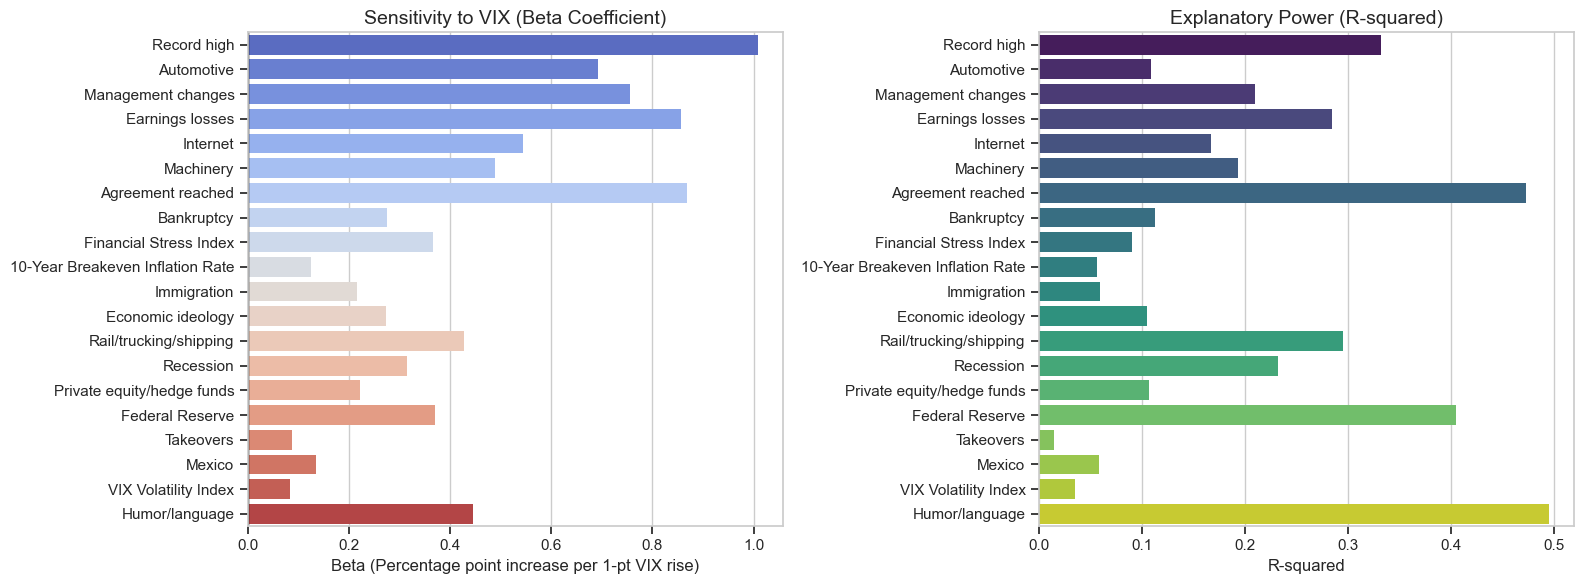

In [17]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure df_vix, xs_sel_rate, top_topics, top_idx, and dates are in memory
N_TOP = 20
results_list = []

print(f"Running HAC Robust OLS Regressions for the Top {N_TOP} Features against Actual VIX...\n")

# 1. Loop through the Top 10 features
for i in range(N_TOP):
    target_idx = top_idx[i]
    target_feature = top_topics[target_idx]
    
    # Y: Cross-Sectional Selection Rate (scaled to 0-100%)
    y_csr = pd.Series(xs_sel_rate[target_idx] * 100, index=dates, name="CSR")
    
    # Combine with the VIX, align dates, and drop NaNs
    reg_df = pd.concat([y_csr, df_vix['Actual_VIX']], axis=1, sort=False).reindex(dates).dropna()
    
    # Run the Time-Series Regression with HAC standard errors
    X = sm.add_constant(reg_df['Actual_VIX'])
    Y = reg_df["CSR"]
    
    model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
    
    # Extract and store the metrics
    results_list.append({
        'Feature': target_feature.replace('_', ' '),
        'Beta (VIX)': model.params['Actual_VIX'],
        't-stat': model.tvalues['Actual_VIX'],
        'p-value': model.pvalues['Actual_VIX'],
        'R-squared': model.rsquared
    })

# 2. Create a clean Summary Table
df_results = pd.DataFrame(results_list)
df_results.set_index('Feature', inplace=True)

print("--- Regression Results: Explanatory Power of VIX on Top 10 Features ---")
display(df_results.round(4)) # Use print() if not in a standard Jupyter frontend

# 3. Visualize the Results: Betas and R-squared side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Betas (Sensitivity to VIX)
sns.barplot(
    x='Beta (VIX)', 
    y=df_results.index, 
    data=df_results, 
    ax=axes[0], 
    palette='coolwarm',
    hue=df_results.index,
    legend=False
)
axes[0].set_title('Sensitivity to VIX (Beta Coefficient)', fontsize=14)
axes[0].set_xlabel('Beta (Percentage point increase per 1-pt VIX rise)', fontsize=12)
axes[0].set_ylabel('')
axes[0].axvline(0, color='black', linewidth=1)

# Subplot 2: R-squared (Explanatory Power)
sns.barplot(
    x='R-squared', 
    y=df_results.index, 
    data=df_results, 
    ax=axes[1], 
    palette='viridis',
    hue=df_results.index,
    legend=False
)
axes[1].set_title('Explanatory Power (R-squared)', fontsize=14)
axes[1].set_xlabel('R-squared', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

--- Hypothesis Test: Does VIX drive the Concentration (Skewness) of Feature Selection? ---
                            OLS Regression Results                            
Dep. Variable:         Selection_Gini   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     71.02
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           7.57e-17
Time:                        16:47:35   Log-Likelihood:                 1771.2
No. Observations:                1657   AIC:                            -3538.
Df Residuals:                    1655   BIC:                            -3528.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

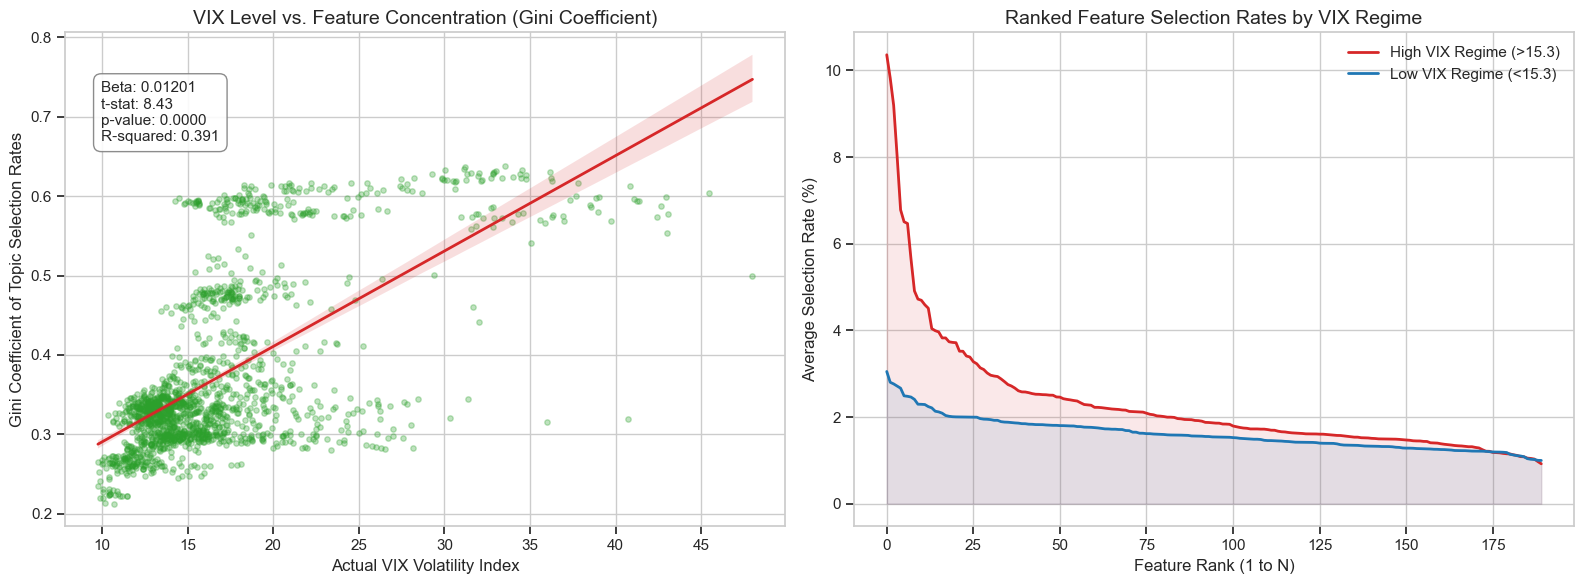

In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Function to calculate the Gini Coefficient (measures inequality/concentration)
def calculate_gini(x):
    """Calculates the Gini coefficient of an array. 0 = Uniform, 1 = Max Skew/Concentration"""
    if np.sum(x) == 0: 
        return 0.0 # Return 0 if no features were selected at all today
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x))

# 2. Calculate daily concentration (Gini) across all topics
# xs_sel_rate is shape (n_topics, n_dates), so we apply along axis 0
daily_gini = np.apply_along_axis(calculate_gini, 0, xs_sel_rate)
y_gini = pd.Series(daily_gini, index=dates, name="Selection_Gini")

# Combine with VIX data and drop NaNs
reg_df = pd.concat([y_gini, df_vix['Actual_VIX']], axis=1, sort=False).reindex(dates).dropna()

# 3. Run HAC Robust OLS Regression
print("--- Hypothesis Test: Does VIX drive the Concentration (Skewness) of Feature Selection? ---")
X = sm.add_constant(reg_df['Actual_VIX'])
Y = reg_df['Selection_Gini']

model_skew = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
print(model_skew.summary())

# 4. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: Scatter of VIX vs Gini ---
sns.regplot(
    x=reg_df['Actual_VIX'], 
    y=reg_df['Selection_Gini'], 
    scatter_kws={'alpha': 0.3, 'color': '#2ca02c', 's': 15}, 
    line_kws={'color': '#d62728', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('VIX Level vs. Feature Concentration (Gini Coefficient)', fontsize=14)
axes[0].set_xlabel('Actual VIX Volatility Index', fontsize=12)
axes[0].set_ylabel('Gini Coefficient of Topic Selection Rates', fontsize=12)

# Annotate regression stats
beta = model_skew.params.iloc[1]
t_stat = model_skew.tvalues.iloc[1]
p_val = model_skew.pvalues.iloc[1]
axes[0].annotate(
    f"Beta: {beta:.5f}\nt-stat: {t_stat:.2f}\np-value: {p_val:.4f}\nR-squared: {model_skew.rsquared:.3f}", 
    xy=(0.05, 0.78), 
    xycoords='axes fraction', 
    fontsize=11, 
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9)
)

# --- Plot B: High VIX vs Low VIX Regimes (Rank-Decay Plot) ---
# Define Regimes based on VIX quartiles
vix_q75 = reg_df['Actual_VIX'].quantile(0.5)
vix_q25 = reg_df['Actual_VIX'].quantile(0.5)

high_vix_days = reg_df[reg_df['Actual_VIX'] >= vix_q75].index
low_vix_days = reg_df[reg_df['Actual_VIX'] <= vix_q25].index

# Get the indices of these days in the original 'dates' array
high_vix_idx = [i for i, d in enumerate(dates) if d in high_vix_days]
low_vix_idx = [i for i, d in enumerate(dates) if d in low_vix_days]

# Average selection rate for each topic in these respective regimes
avg_sel_high = xs_sel_rate[:, high_vix_idx].mean(axis=1) * 100
avg_sel_low = xs_sel_rate[:, low_vix_idx].mean(axis=1) * 100

# Sort in descending order to show the skew/decay curve
avg_sel_high_sorted = np.sort(avg_sel_high)[::-1]
avg_sel_low_sorted = np.sort(avg_sel_low)[::-1]

axes[1].plot(avg_sel_high_sorted, label=f'High VIX Regime (>{vix_q75:.1f})', color='#d62728', linewidth=2)
axes[1].plot(avg_sel_low_sorted, label=f'Low VIX Regime (<{vix_q25:.1f})', color='#1f77b4', linewidth=2)
axes[1].fill_between(range(len(avg_sel_high_sorted)), avg_sel_high_sorted, alpha=0.1, color='#d62728')
axes[1].fill_between(range(len(avg_sel_low_sorted)), avg_sel_low_sorted, alpha=0.1, color='#1f77b4')

axes[1].set_title('Ranked Feature Selection Rates by VIX Regime', fontsize=14)
axes[1].set_xlabel('Feature Rank (1 to N)', fontsize=12)
axes[1].set_ylabel('Average Selection Rate (%)', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()